# Chapter 33: Data Augmentation for Tabular Data

**How much does resampling before the split inflate cross-validation, and does resampling inside the fold beat weighting or doing nothing?**

Imbalanced tasks tempt a quick fix, and the quick version (resample the table, then cross-validate) produces a large, convincing gain that is not real. Measuring the estimate against new rows shows how large the artefact is and whether any real gain remains.

*Constructed data; the sizes of these effects are properties of this generator, not a competition result. Resampling did not help here, and the text does not claim it never does.*

## The experiment

Eight constructed datasets of 4,000 rows and ten features; the minority class (prevalence is the control) is shifted by 0.6 to 1.0 standard deviations on three features. A histogram gradient boosting classifier is scored by average precision (AP), pooled over 3-fold cross-validation and measured on 8,000 new rows, under four policies: no resampling, class weights, SMOTE inside each training fold, and SMOTE on the full training set before the folds are drawn (validation rows then include synthetic neighbours in training; only original rows are scored). SMOTE here is written out in numpy: interpolate to a random one of the 5 nearest minority neighbours until the classes balance.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors

from kaggle_companion.activities._common import clean

SEED = 33
REPLICATES = 8          # independent constructed datasets; every estimate is their mean
N_TRAIN, N_NEW, FEATURES = 4000, 8000, 10


def generate(n, prevalence, rng):
    """Ten standard-normal features; the minority class is shifted by 1.0, 0.8 and 0.6 standard deviations on the first three."""
    y = (rng.random(n) < prevalence).astype(int)
    X = rng.normal(size=(n, FEATURES))
    X[:, :3] += y[:, None] * np.array([1.0, 0.8, 0.6])
    return X, y


def smote(X, y, rng, k=5):
    """Interpolate between each minority row and one of its k nearest minority neighbours until the classes are balanced."""
    minority = X[y == 1]
    need = int((y == 0).sum() - len(minority))
    if need <= 0 or len(minority) < 2:
        return X, y
    k = min(k, len(minority) - 1)
    neighbours = NearestNeighbors(n_neighbors=k + 1).fit(minority).kneighbors(minority)[1][:, 1:]   # column 0 is the row itself
    start = rng.integers(0, len(minority), need)
    partner = neighbours[start, rng.integers(0, k, need)]
    synthetic = minority[start] + rng.random((need, 1)) * (minority[partner] - minority[start])
    return np.vstack([X, synthetic]), np.concatenate([y, np.ones(need, int)])


def model(class_weight=None):
    return HistGradientBoostingClassifier(max_iter=30, max_leaf_nodes=8, max_bins=32, learning_rate=0.1,
                                          class_weight=class_weight, random_state=0)


def one_replicate(prevalence, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(N_TRAIN, prevalence, rng)
    X_new, y_new = generate(N_NEW, prevalence, rng)             # new rows from the same generator: the "truth"
    folds = list(StratifiedKFold(3, shuffle=True, random_state=1).split(X, y))

    def pooled_cv(fit_predict):
        """Pool the held-out predictions of all folds and compute one average precision over them."""
        pooled = np.zeros(N_TRAIN)
        for train, valid in folds:
            pooled[valid] = fit_predict(train, valid)
        return average_precision_score(y, pooled)

    out = {}
    out["none"] = (pooled_cv(lambda a, b: model().fit(X[a], y[a]).predict_proba(X[b])[:, 1]),
                   average_precision_score(y_new, model().fit(X, y).predict_proba(X_new)[:, 1]))
    out["weight"] = (pooled_cv(lambda a, b: model("balanced").fit(X[a], y[a]).predict_proba(X[b])[:, 1]),
                     average_precision_score(y_new, model("balanced").fit(X, y).predict_proba(X_new)[:, 1]))

    def smote_in_fold(train, valid):                            # resample the training fold only; validation rows stay untouched
        Xr, yr = smote(X[train], y[train], np.random.default_rng(seed + int(train[0])))
        return model().fit(Xr, yr).predict_proba(X[valid])[:, 1]

    X_all, y_all = smote(X, y, np.random.default_rng(seed + 1))   # SMOTE on the whole training set: the shortcut
    deployed = average_precision_score(y_new, model().fit(X_all, y_all).predict_proba(X_new)[:, 1])
    out["inside"] = (pooled_cv(smote_in_fold), deployed)

    # SMOTE before the split: cross-validate the resampled table, so synthetic rows built from a validation row's neighbours
    # sit in the training folds. Scoring only the original rows keeps the class balance honest; scoring everything is worse.
    pooled = np.zeros(len(y_all))
    for train, valid in StratifiedKFold(3, shuffle=True, random_state=1).split(X_all, y_all):
        pooled[valid] = model().fit(X_all[train], y_all[train]).predict_proba(X_all[valid])[:, 1]
    original = np.arange(len(y_all)) < N_TRAIN
    out["before"] = (average_precision_score(y_all[original], pooled[original]), deployed)
    out["before_all_rows"] = (average_precision_score(y_all, pooled), deployed)
    return out


def run(prevalence):
    reps = [one_replicate(prevalence, SEED * 100 + i) for i in range(REPLICATES)]
    result = {"prevalence": prevalence, "replicates": REPLICATES, "training_rows": N_TRAIN, "new_rows": N_NEW,
              "training_positives": round(N_TRAIN * prevalence)}
    for name in ("none", "weight", "inside", "before", "before_all_rows"):
        result[name] = {"cv": float(np.mean([r[name][0] for r in reps])), "new_rows": float(np.mean([r[name][1] for r in reps]))}
    return clean(result)


## Measure it across the control

The control is **minority class share of the rows**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch33 import explain

VALUES = [0.02, 0.05, 0.15, 0.3]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                          0.02   0.05   0.15    0.3
Pre-split CV AP          0.233  0.302  0.512  0.685
Inside-fold CV AP        0.091  0.202  0.481  0.675
SMOTE, new rows          0.097  0.226  0.491  0.686
No resampling, new rows  0.106  0.234  0.505  0.693
Class weights, new rows  0.111  0.246  0.506  0.692


## Look at it

The figure shows the default setting, minority class share of the rows = 0.05.

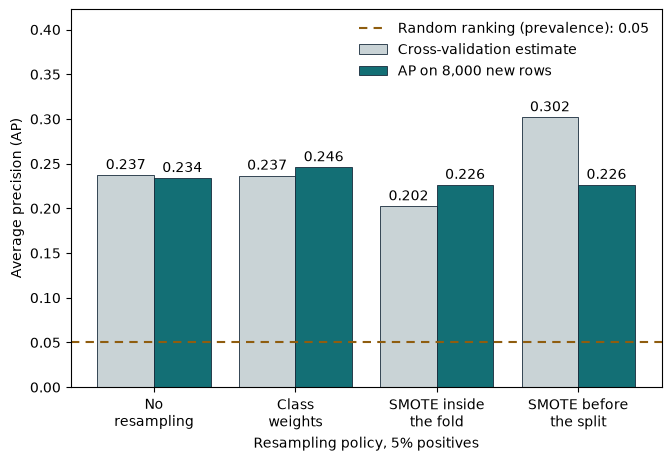

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch33 import draw, NCOLS, HEIGHT

DEFAULT = 0.05
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 5% positives, SMOTE before the split reports AP 0.302 but the model scores 0.226 on new rows, 0.302 - 0.226 = 0.076 of optimism (scoring the synthetic rows too reports 0.879). Inside the fold the estimate is 0.202 against 0.226 on new rows. Against 0.234 for no resampling, SMOTE inside the fold changes AP by -0.008 and class weights by +0.012.

- SMOTE before the split: 0.302 - 0.226 = 0.076 (estimate minus new rows).
- SMOTE inside the fold: 0.202 - 0.226 = -0.024.
- Value of SMOTE on new rows: 0.226 - 0.234 = -0.008.
- Value of class weights on new rows: 0.246 - 0.234 = +0.012.

## Apply this to your competition

- Never resample the table before the folds are drawn; put the resampler in a pipeline so it fits on the training fold only.
- Score validation folds on untouched rows and keep the no-resampling baseline on the same folds.
- Compare against class weights or loss reweighting first: they add no synthetic rows and are cheaper to validate.
- Check calibration and threshold choice separately, because resampling and weighting change the predicted probabilities.

Book location: Chapter 33, SMOTE and Oversampling: Handle With Care.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)